<a href="https://colab.research.google.com/github/JonHemrick/ECGR4106/blob/HW1/HW1Problem2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
class AdaptedVGG11(nn.Module):
    def __init__(self, num_classes=10, dropout=0.0, use_batchnorm=False):
        super(AdaptedVGG11, self).__init__()

        def conv_block(in_channels, out_channels, num_convs):
            layers = []
            for i in range(num_convs):
                layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
                if use_batchnorm:
                    layers.append(nn.BatchNorm2d(out_channels))
                layers.append(nn.ReLU(inplace=True))
                in_channels = out_channels
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            return layers

        self.features = nn.Sequential(
            *conv_block(3, 64, 1),
            *conv_block(64, 128, 1),
            *conv_block(128, 256, 2),
            *conv_block(256, 512, 2),
            *conv_block(512, 512, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
vgg_model = AdaptedVGG11(dropout=0.0, use_batchnorm=False).to(device)
print("VGG-11 parameters:", count_parameters(vgg_model))

VGG-11 parameters: 9354378


In [ ]:
def train_model(model, trainloader, testloader, criterion, optimizer, epochs=10):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        epoch_start = time.time()

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(trainloader)
        train_acc = 100 * correct / total

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(testloader)
        val_acc = 100 * correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        epoch_time = time.time() - epoch_start

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | "
              f"Time: {epoch_time:.2f}s")

    total_time = time.time() - start_time

    return train_losses, val_losses, train_accs, val_accs, total_time

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Image preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

# Load CIFAR-10 training set
trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Load CIFAR-10 test set
testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Data loaders
trainloader = DataLoader(
    trainset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

testloader = DataLoader(
    testset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Train batches:", len(trainloader))
print("Test batches:", len(testloader))

Train batches: 782
Test batches: 157


In [ ]:
vgg_model = AdaptedVGG11(dropout=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg_model.parameters(), lr=0.001)

vgg_train_losses, vgg_val_losses, vgg_train_accs, vgg_val_accs, vgg_time = train_model(
    vgg_model,
    trainloader,
    testloader,
    criterion,
    optimizer,
    epochs=10
)

print("Total VGG training time:", vgg_time)
print("VGG parameters:", count_parameters(vgg_model))
torch.save(vgg_model.state_dict(), "/content/drive/MyDrive/vgg11_partA.pth")


Epoch [1/10] Train Loss: 1.8447, Train Acc: 27.98% | Val Loss: 1.4481, Val Acc: 46.24% | Time: 20.58s
Epoch [2/10] Train Loss: 1.3310, Train Acc: 50.99% | Val Loss: 1.2482, Val Acc: 54.35% | Time: 21.68s
Epoch [3/10] Train Loss: 1.1394, Train Acc: 58.79% | Val Loss: 1.1297, Val Acc: 59.96% | Time: 20.13s
Epoch [4/10] Train Loss: 0.9932, Train Acc: 64.87% | Val Loss: 1.0466, Val Acc: 63.69% | Time: 21.94s
Epoch [5/10] Train Loss: 0.8967, Train Acc: 68.33% | Val Loss: 0.9503, Val Acc: 66.88% | Time: 20.20s
Epoch [6/10] Train Loss: 0.8137, Train Acc: 71.44% | Val Loss: 0.9349, Val Acc: 68.06% | Time: 22.77s
Epoch [7/10] Train Loss: 0.7415, Train Acc: 74.13% | Val Loss: 0.9510, Val Acc: 68.92% | Time: 20.22s
Epoch [8/10] Train Loss: 0.6844, Train Acc: 76.01% | Val Loss: 0.8896, Val Acc: 70.51% | Time: 21.70s
Epoch [9/10] Train Loss: 0.6242, Train Acc: 78.19% | Val Loss: 0.9117, Val Acc: 70.84% | Time: 20.39s
Epoch [10/10] Train Loss: 0.5693, Train Acc: 80.01% | Val Loss: 0.8467, Val Acc: 7

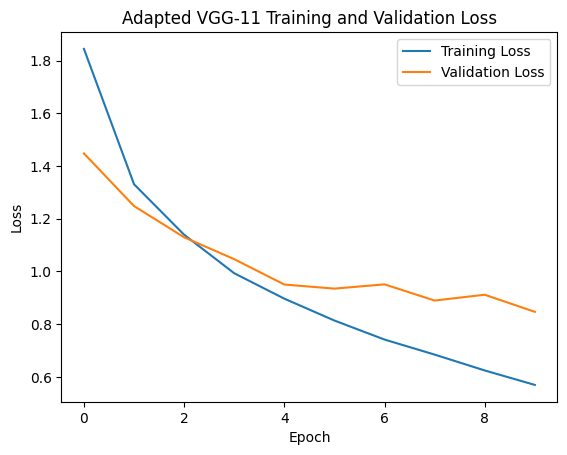

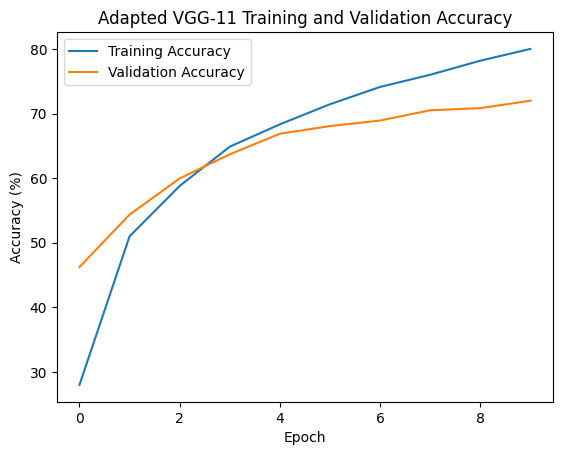

In [ ]:
plt.figure()
plt.plot(vgg_train_losses, label="Training Loss")
plt.plot(vgg_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Adapted VGG-11 Training and Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(vgg_train_accs, label="Training Accuracy")
plt.plot(vgg_val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Adapted VGG-11 Training and Validation Accuracy")
plt.legend()
plt.show()

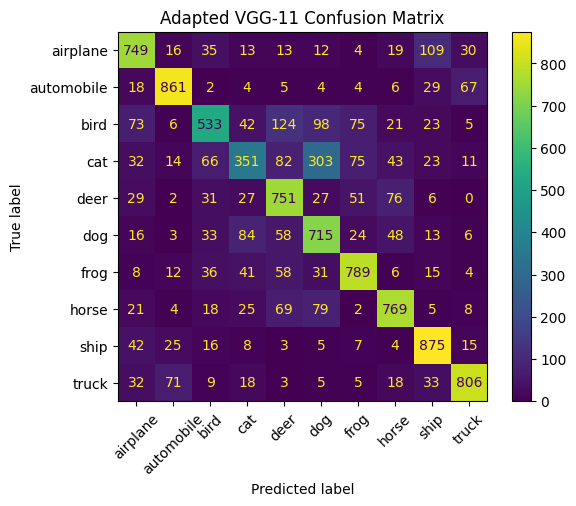

In [ ]:
def plot_confusion_matrix(model, testloader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(xticks_rotation=45)
    plt.title("Adapted VGG-11 Confusion Matrix")
    plt.show()
    class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

plot_confusion_matrix(vgg_model, testloader, class_names)

PART B

In [ ]:
dropout_results = {}

for dropout_rate in [0.0, 0.3, 0.5]:
    print(f"\nTraining VGG-11 with dropout = {dropout_rate}")

    model = AdaptedVGG11(dropout=dropout_rate, use_batchnorm=False).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses, train_accs, val_accs, total_time = train_model(
        model,
        trainloader,
        testloader,
        criterion,
        optimizer,
        epochs=10
    )

    dropout_results[dropout_rate] = {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "time": total_time,
        "params": count_parameters(model)
    }

    torch.save(model.state_dict(), f"vgg11_dropout_{dropout_rate}.pth")


Training VGG-11 with dropout = 0.0
Epoch [1/10] Train Loss: 1.7953, Train Acc: 29.64% | Val Loss: 1.4637, Val Acc: 42.87% | Time: 20.52s
Epoch [2/10] Train Loss: 1.3264, Train Acc: 50.08% | Val Loss: 1.1216, Val Acc: 59.60% | Time: 21.82s
Epoch [3/10] Train Loss: 1.0248, Train Acc: 63.18% | Val Loss: 0.9944, Val Acc: 64.71% | Time: 20.28s
Epoch [4/10] Train Loss: 0.8710, Train Acc: 69.21% | Val Loss: 0.9206, Val Acc: 67.84% | Time: 21.85s
Epoch [5/10] Train Loss: 0.7477, Train Acc: 73.69% | Val Loss: 0.8925, Val Acc: 69.82% | Time: 20.11s
Epoch [6/10] Train Loss: 0.6549, Train Acc: 77.14% | Val Loss: 0.7947, Val Acc: 73.69% | Time: 21.43s
Epoch [7/10] Train Loss: 0.5679, Train Acc: 80.02% | Val Loss: 0.8146, Val Acc: 73.42% | Time: 20.74s
Epoch [8/10] Train Loss: 0.5005, Train Acc: 82.38% | Val Loss: 0.8624, Val Acc: 73.00% | Time: 20.55s
Epoch [9/10] Train Loss: 0.4268, Train Acc: 85.12% | Val Loss: 0.8591, Val Acc: 74.49% | Time: 21.55s
Epoch [10/10] Train Loss: 0.3743, Train Acc: 8

In [ ]:
for dropout_rate, results in dropout_results.items():
    print(f"Dropout: {dropout_rate}")
    print(f"Final Train Accuracy: {results['train_accs'][-1]:.2f}%")
    print(f"Final Validation Accuracy: {results['val_accs'][-1]:.2f}%")
    print(f"Training Time: {results['time']:.2f} seconds")
    print(f"Parameters: {results['params']}")
    print()

Dropout: 0.0
Final Train Accuracy: 87.01%
Final Validation Accuracy: 74.17%
Training Time: 209.00 seconds
Parameters: 9354378

Dropout: 0.3
Final Train Accuracy: 87.06%
Final Validation Accuracy: 74.12%
Training Time: 209.08 seconds
Parameters: 9354378

Dropout: 0.5
Final Train Accuracy: 85.75%
Final Validation Accuracy: 73.69%
Training Time: 206.28 seconds
Parameters: 9354378



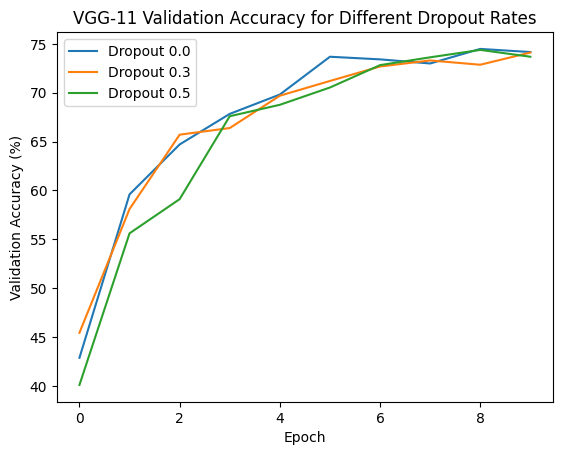

In [ ]:
plt.figure()

for dropout_rate, results in dropout_results.items():
    plt.plot(results["val_accs"], label=f"Dropout {dropout_rate}")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("VGG-11 Validation Accuracy for Different Dropout Rates")
plt.legend()
plt.show()